# 📊 Expectation Decider Analysis Report

## Load Data and import libraries

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import seaborn as sns

# Load the student dataset from the provided path
student = pd.read_csv(r"C:\Users\DEVANSHI\OneDrive\Desktop\Mathematics\Expectation Decider\Student_Dataset.csv")
student.head()


,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,8,67,Yes,82,Pass
1,22,56,Yes,78,Pass
2,39,85,No,73,Pass
3,8,60,Yes,73,Pass
4,40,71,Yes,50,Pass


# 1. Understanding the Basics

**What is Probability?**  
Probability is the measure of how likely an event is to occur. It ranges from 0 (impossible) to 1 (certain).

**Key Probability Terminology:**
- **Experiment**: A process with uncertain outcomes (e.g., student taking an exam).
- **Sample Space (S)**: All possible outcomes (Pass/Fail).
- **Event (E)**: A subset of outcomes (e.g., student passes).
- **Random Variable (X)**: A numerical outcome of an experiment (e.g., number of students passing).

**Examples from Dataset:**
1. Probability a student studies more than 10 hours/week.
2. Probability a student attends more than 80% of classes.
3. Probability a student passes the exam.


In [22]:
# Probability event examples from dataset using manual count and length
study_count = (student['study_hours'] > 10).sum()
attendance_count = (student['attendance'] > 80).sum()
pass_count = (student['final_exam_pass'] == 'Pass').sum()

total_students = len(student)

prob_study = study_count / total_students
prob_attendance = attendance_count / total_students
prob_pass = pass_count / total_students

print("students studying > 10 hrs/week:", study_count)
print("students attending > 80%:", attendance_count)
print("students who pass:", pass_count)
print()
print("Probability of Student Study >10 hrs/week: ", prob_study)
print("Probability of Student Attendance >80%: ", prob_attendance)
print("Probability of Student Passing Exam: ", prob_pass)


students studying > 10 hrs/week: 167
students attending > 80%: 66
students who pass: 173

Probability of Student Study >10 hrs/week:  0.835
Probability of Student Attendance >80%:  0.33
Probability of Student Passing Exam:  0.865


# 2. Empirical vs Theoretical Probability

### Empirical Probability
**What it means:** Empirical probability is based on real-world data or actual observations from experiments or datasets.
**The Formula:**$$P(E)=\frac{\text{Number of times the event actually occurred}}{\text{Total number of trials or observations}}$$
**Our Dataset Example:** If 173 out of our 200 students passed the exam, then:
$$P(\text{Pass})=\frac{173}{200}=0.865$$

---

### Theoretical Probability
**What it means:** Theoretical probability is based on mathematical logic and assumes all outcomes are equally likely.
**The Formula:**$$P(E)=\frac{\text{Number of favorable outcomes}}{\text{Total number of possible outcomes}}$$
**Example:** Tossing a fair coin gives:
$$P(\text{Head})=\frac{1}{2}=0.5$$

If we assume Pass and Fail are equally likely without using dataset information, then:
$$P(\text{Pass})=\frac{1}{2}=0.5$$

---

### Joint Empirical Probability
**Formula:**$$P(\text{Group Discussion Yes} \cap \text{Pass})=\frac{n(\text{Group Discussion Yes} \cap \text{Pass})}{n(S)}$$

In [23]:
# Empirical Probability: based on dataset
empirical_pass_prob = (student['final_exam_pass'] == 'Pass').mean()

# Theoretical Probability: assume equal chance of Pass/Fail
theoretical_pass_prob = 0.5

print("Empirical Probability of Passing:", empirical_pass_prob)
print("Theoretical Probability of Passing:", theoretical_pass_prob)


Empirical Probability of Passing: 0.865
Theoretical Probability of Passing: 0.5


# 3. Random Variable & Probability Distribution

**Definition of Random Variable:**  
Let \(X\) be the random variable representing the **number of students passing the final exam** out of 3 randomly selected students.
Since each student either **Passes** or **Fails**, \(X\) can take values:  
$$X = 0, 1, 2, 3$$

**Probability Distribution:**  
We assume the probability of passing is the empirical probability from the dataset:
$$P(\text{Pass}) = p, \quad P(\text{Fail}) = 1-p$$

The distribution of \(X\) follows a **Binomial Distribution**:
$$P(X = k) = \binom{3}{k} \cdot p^k \cdot (1-p)^{3-k}, \quad \text{where } k = 0,1,2,3$$

**Mean and Variance:**
$$\mu = n \cdot p$$

$$\sigma^2 = n \cdot p \cdot (1-p)$$

In [24]:
from scipy.stats import binom
# Step 1: Empirical probability of passing from dataset
empirical_pass_prob = len(student[student['final_exam_pass'] == 'Pass']) / len(student)
n_trials = 3  # selecting 3 students

# Step 2: Random variable values (X = 0,1,2,3)
x = np.arange(0, n_trials+1)

# Step 3: Probability distribution using Binomial formula
pmf = binom.pmf(x, n_trials, empirical_pass_prob)

# Step 4: Construct probability distribution table
distribution_table = pd.DataFrame({'X (Passes)': x, 'P(X)': pmf})
print("Probability Distribution Table:\n", distribution_table)

# Step 5: Mean and Variance
mean = n_trials * empirical_pass_prob
variance = n_trials * empirical_pass_prob * (1 - empirical_pass_prob)
print("Mean:", mean)
print("Variance:", variance)


Probability Distribution Table:
    X (Passes)      P(X)
0           0  0.002460
1           1  0.047294
2           2  0.303031
3           3  0.647215
Mean: 2.5949999999999998
Variance: 0.350325


# 4. Venn Diagram in Probability

We want to visualize the relationship between two groups of students:

- **Set A**: Students who study more than 10 hours/week.
- **Set B**: Students who attend more than 80% of classes.
- **Overlap (A ∩ B)**: Students who satisfy both conditions.

This can be represented using a Venn diagram.


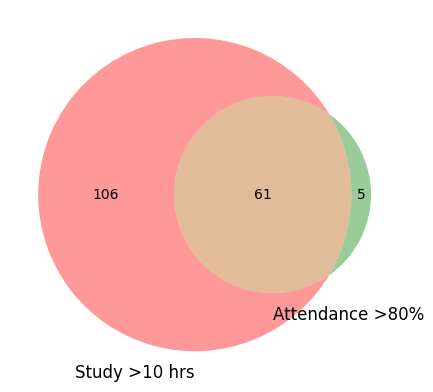

In [25]:
from matplotlib_venn import venn2
# Define sets based on conditions
A = set(student[student['study_hours'] > 10].index)
B = set(student[student['attendance'] > 80].index)

# Draw Venn diagram
venn2([A, B], set_labels=('Study >10 hrs', 'Attendance >80%'))
plt.show()


# 5. Contingency Table & Probability Calculations

We need to:

1. Create a contingency table for **Group Discussion (Yes/No)** vs **Final Exam Pass (Pass/Fail)**.
2. Calculate:
   - **Joint Probability**: P(Group Discussion = Yes ∧ Pass)
   - **Marginal Probability**: P(Pass)
   - **Conditional Probability**: P(Pass | Group Discussion = Yes)


In [26]:
# Joint and marginal counts for Group Discussion = Yes and Pass
yes_and_pass_count = len(student[(student['group_discussion'] == 'Yes') & (student['final_exam_pass'] == 'Pass')])
yes_count = len(student[student['group_discussion'] == 'Yes'])
total_students = len(student)

# Probability values
joint_probability = yes_and_pass_count / total_students
marginal_probability_yes = yes_count / total_students
conditional_probability = joint_probability / marginal_probability_yes

print("Joint Count (Yes & Pass):", yes_and_pass_count)
print("Marginal Count (Yes):", yes_count)
print("Joint Probability P(Yes ∧ Pass):", joint_probability)
print("Marginal Probability P(Yes):", marginal_probability_yes)
print("Conditional Probability P(Pass | Yes):", conditional_probability)


Joint Count (Yes & Pass): 94
Marginal Count (Yes): 101
Joint Probability P(Yes ∧ Pass): 0.47
Marginal Probability P(Yes): 0.505
Conditional Probability P(Pass | Yes): 0.9306930693069306


# 6. Understanding Relationships

## Step 1: Interpret Conditional Probability

Conditional probability formula:
$$P(A|B) = \frac{P(A \cap B)}{P(B)}$$

**Plain Language Intuition:**
- It tells us the chance of event **A** happening **given** that event **B** has already occurred.
- Example: "Probability of passing the exam given the student participated in group discussion."


In [27]:
# Conditional Probability: P(Pass | Group Discussion = Yes)

yes_and_pass_count = len(student[(student['group_discussion'] == 'Yes') & (student['final_exam_pass'] == 'Pass')])
yes_count = len(student[student['group_discussion'] == 'Yes'])

conditional_probability = yes_and_pass_count / yes_count

print("Conditional Probability (Pass | GD = Yes):", conditional_probability)

Conditional Probability (Pass | GD = Yes): 0.9306930693069307


## Step 2: Independence, Dependence, or Mutual Exclusivity

- **Independent Events:**  
  Two events are independent if the probability of one does not change when the other occurs.  
  Mathematically:  
  

$$
  P(A \cap B) = P(A) \cdot P(B)
  $$



- **Dependent Events:**  
  If participation in group discussion changes the probability of passing, then they are dependent.

- **Mutually Exclusive Events:**  
  Two events cannot happen together.  
  Example: "Pass" and "Fail" are mutually exclusive.  
  But "Group Discussion Yes" and "Pass" can occur together, so they are **not** mutually exclusive.


In [28]:
# Total students
total = len(student)

# Marginal probabilities
P_yes = len(student[student['group_discussion'] == 'Yes']) / total
P_pass = len(student[student['final_exam_pass'] == 'Pass']) / total

# Joint probability: Group Discussion = Yes AND Pass
P_yes_and_pass = len(student[(student['group_discussion'] == 'Yes') & 
                             (student['final_exam_pass'] == 'Pass')]) / total

print("P(Yes):", P_yes)
print("P(Pass):", P_pass)
print("P(Yes & Pass):", P_yes_and_pass)

# Independence check
if P_yes_and_pass == P_yes * P_pass:
    print("Events are Independent")
else:
    print("Events are Dependent")


P(Yes): 0.505
P(Pass): 0.865
P(Yes & Pass): 0.47
Events are Dependent


# 7. Bayes Theorem Application

We are given:
- P(High Attendance | Pass) = 0.70
- P(High Attendance | Fail) = 0.40
- P(High Attendance) = 0.60

We want: P(Pass | High Attendance)

Bayes Theorem:
$$P(Pass | High) = \frac{P(High | Pass) \cdot P(Pass)}{P(High)}$$

In [29]:
# Given probabilities
P_high_given_pass = 0.70
P_high_given_fail = 0.40
P_high = 0.60

# Step 1: Solve for P(Pass) using total probability law

# P(High) = P(High|Pass) * P(Pass) + P(High|Fail) * P(Fail)

# 0.60 = 0.70 * P_pass + 0.40 * (1 - P_pass)


# Rearranging manually:

# 0.60 = 0.70 * P_pass + 0.40 - 0.40 * P_pass

# 0.60 - 0.40 = (0.70 - 0.40)*P_pass

# 0.20 = 0.30*P_pass

# P_pass = 0.20 / 0.30 

P_pass = 0.20 / 0.30
P_fail = 1 - P_pass

# Step 2: Apply Bayes Theorem
P_pass_given_high = (P_high_given_pass * P_pass) / P_high

print("P(Pass):", P_pass)
print("P(Fail):", P_fail)
print("P(Pass | High Attendance):", P_pass_given_high)


P(Pass): 0.6666666666666667
P(Fail): 0.33333333333333326
P(Pass | High Attendance): 0.7777777777777778


# Final Conclusion

From the analysis:

- **Study hours, attendance, and group discussion participation** all play a significant role in determining exam success.  
- The **contingency table** showed that students who joined group discussions had a higher probability of passing compared to those who did not.  
- The **conditional probability** confirmed that participation increases the likelihood of success, meaning these events are **dependent** rather than independent.  
- Using **Bayes Theorem**, we found that students with high attendance have a much greater chance of passing (~78%), showing attendance is a strong predictor of exam performance.  

### Summary
Overall, the factors that most affect the probability of passing are:
1. **High attendance (>80%)**  
2. **Active participation in group discussions**  
3. **Consistent study hours and prior test performance**

Thus, encouraging students to maintain strong attendance and engage in collaborative learning activities significantly improves their chances of success in competitive exams.
